# Properties of the Derivative — The Sum Rule

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **sum rule**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- the rule: if $f = g + h$, then $f' = g' + h'$
- the **boat-and-child** intuition (distances add ⟹ velocities add ⟹ derivatives add)
- the plot argument ($x_{\text{total}} = x_b + x_c$, divide by $\Delta t$, take the limit)
- SymPy verification and examples combining the sum and scalar rules

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Properties of the Derivative — Multiplication by Scalars*.

## 1. The rule

If a function is the **sum** of two functions, its derivative is the **sum** of their
derivatives:

$$
f(x) = g(x) + h(x) \quad\Longrightarrow\quad f'(x) = g'(x) + h'(x).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
g = sp.Function('g'); h = sp.Function('h')
print("d/dx [g(x) + h(x)] =", sp.diff(g(x) + h(x), x))

d/dx [g(x) + h(x)] = Derivative(g(x), x) + Derivative(h(x), x)


## 2. Intuition: a boat and a child

Picture a **child running inside a moving boat**. The boat moves a distance, and the child
moves a distance *inside* the boat.

- Boat moves $x_b = 10$, child moves $x_c = 2$ (same direction).
- The child's distance **relative to the Earth** is $x_b + x_c = 12$ — distances **add**.

The same goes for **velocities**. If the boat's speed is $0.6$ m/s and the child's speed
(inside the boat) is $0.05$ m/s, the child's speed relative to the Earth is

$$
0.6 + 0.05 = 0.65 \text{ m/s}.
$$

> *"If distances can be added, then velocities can also be added — which means if functions
> can be added, then their derivatives can be added."*

In [2]:
x_boat, x_child = 10, 2
print(f"distance relative to Earth = {x_boat} + {x_child} = {x_boat + x_child}")

v_boat, v_child = 0.6, 0.05
print(f"velocity relative to Earth = {v_boat} + {v_child} = {v_boat + v_child} m/s")

distance relative to Earth = 10 + 2 = 12
velocity relative to Earth = 0.6 + 0.05 = 0.65 m/s


## 3. The plot argument

Plot distance vs. time for the child (inside the boat), the boat, and their sum. Over a
small interval $\Delta t$, the vertical steps satisfy

$$
x_{\text{total}} = x_b + x_c .
$$

Dividing through by the **same** $\Delta t$ gives the average velocities adding:

$$
\frac{x_{\text{total}}}{\Delta t} = \frac{x_b}{\Delta t} + \frac{x_c}{\Delta t}
\quad\Longrightarrow\quad v_{\text{total}} = v_b + v_c .
$$

Letting $\Delta t \to 0$ turns these into derivatives:

$$
\boxed{\;(f_1 + f_2)'(x) = f_1'(x) + f_2'(x).\;}
$$

In [3]:
# the sum of two functions has slope = sum of the slopes
f1 = sp.sin(x)
f2 = x**2
print("f1 =", f1, ", f1' =", sp.diff(f1, x))
print("f2 =", f2, ", f2' =", sp.diff(f2, x))
print("d/dx (f1 + f2) =", sp.diff(f1 + f2, x), " = f1' + f2'")

# check the slopes add at a sample point
x0 = 1.0
s1 = float(sp.diff(f1, x).subs(x, x0))
s2 = float(sp.diff(f2, x).subs(x, x0))
ss = float(sp.diff(f1 + f2, x).subs(x, x0))
print(f"\nat x=1:  f1'={s1:.4f} + f2'={s2:.4f} = {s1+s2:.4f}  vs  (f1+f2)'={ss:.4f}")

f1 = sin(x) , f1' = cos(x)
f2 = x**2 , f2' = 2*x
d/dx (f1 + f2) = 2*x + cos(x)  = f1' + f2'

at x=1:  f1'=0.5403 + f2'=2.0000 = 2.5403  vs  (f1+f2)'=2.5403


## 4. Combining with the scalar rule

Together, the **scalar** and **sum** rules let us differentiate any polynomial (and many
other combinations) term by term.

In [4]:
for expr in [3*x**2 + 5*x, x**3 - 2*x**2 + 7, sp.sin(x) + sp.exp(x) - sp.log(x)]:
    print(f"d/dx [{expr}] = {sp.diff(expr, x)}")

d/dx [3*x**2 + 5*x] = 6*x + 5
d/dx [x**3 - 2*x**2 + 7] = 3*x**2 - 4*x
d/dx [exp(x) - log(x) + sin(x)] = exp(x) + cos(x) - 1/x


### Visualizing slopes adding

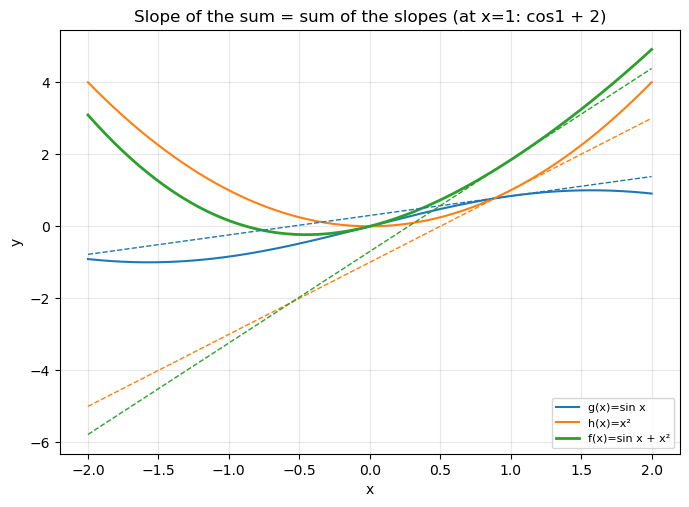

In [5]:
xs = np.linspace(-2, 2, 200)
g_ = np.sin(xs); h_ = xs**2; s_ = g_ + h_

plt.figure(figsize=(8, 5.5))
plt.plot(xs, g_, label="g(x)=sin x")
plt.plot(xs, h_, label="h(x)=x²")
plt.plot(xs, s_, label="f(x)=sin x + x²", lw=2)
# tangents at x=1
x0 = 1.0
for fn, dfn, col, lab in [(np.sin(1), np.cos(1), "tab:blue", "g"),
                          (1**2, 2*1, "tab:orange", "h"),
                          (np.sin(1)+1, np.cos(1)+2, "tab:green", "f")]:
    plt.plot(xs, fn + dfn*(xs-1), "--", color=col, lw=1)
plt.title("Slope of the sum = sum of the slopes (at x=1: cos1 + 2)")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.show()

## 5. Exercises

### Basic
1. State the sum rule.
2. If $g'(x) = \cos x$ and $h'(x) = 2x$, what is $(g+h)'(x)$?

### Intermediate
3. Differentiate $f(x) = x^3 + \sin x$.
4. Differentiate $f(x) = 4x^2 - 3x + e^x$ (sum + scalar rules).

### Advanced
5. Show from the limit definition that $(f_1 + f_2)' = f_1' + f_2'$.
6. In the boat analogy, what happens to the child's speed relative to Earth if the child
   runs *against* the boat's direction?

## 6. Solutions / Checks

In [6]:
x = sp.symbols('x')

# 3 & 4
print("3. d/dx (x³ + sin x) =", sp.diff(x**3 + sp.sin(x), x))
print("4. d/dx (4x² - 3x + eˣ) =", sp.diff(4*x**2 - 3*x + sp.exp(x), x))

# 5.
h_, f1, f2 = sp.symbols('h'), sp.Function('f1'), sp.Function('f2')
print("5. limit definition:", sp.diff(f1(x) + f2(x), x))

print("\n1. (g+h)' = g' + h'.")
print("2. (g+h)'(x) = cos x + 2x.")
print("6. Running against the boat subtracts: v_total = v_boat - v_child (signed velocities add).")

3. d/dx (x³ + sin x) = 3*x**2 + cos(x)
4. d/dx (4x² - 3x + eˣ) = 8*x + exp(x) - 3
5. limit definition: Derivative(f1(x), x) + Derivative(f2(x), x)

1. (g+h)' = g' + h'.
2. (g+h)'(x) = cos x + 2x.
6. Running against the boat subtracts: v_total = v_boat - v_child (signed velocities add).


## 7. Conclusion

- The **sum rule**: $\dfrac{d}{dx}\big[g(x) + h(x)\big] = g'(x) + h'(x)$.
- Intuition: a child in a moving boat — distances add, so velocities add, so derivatives
  add ($0.6 + 0.05 = 0.65$ m/s).
- Combined with the scalar rule, it differentiates any polynomial or sum **term by term**.
- Next: the **product rule** (for $g\cdot h$), which is *not* just the product of
  derivatives.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (18).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **properties of the derivative — the sum rule**. Key spoken
points, lightly cleaned:

> The sum rule: if $f = g + h$, then $f' = g' + h'$. Imagine a child running inside a moving
> boat: the boat moves $10$ and the child moves $2$ inside it, so relative to the Earth the
> child moves $12$ — distances add. The same holds for velocities: a boat at $0.6$ m/s and a
> child at $0.05$ m/s in the same direction give $0.65$ m/s relative to Earth. So if
> distances add, velocities add, and if functions add, their derivatives add. On a
> distance–time plot, over an interval $\Delta t$, $x_{\text{total}} = x_b + x_c$; dividing
> by $\Delta t$ gives $v_{\text{total}} = v_b + v_c$, and letting $\Delta t \to 0$ gives the
> derivatives: $(f_1 + f_2)' = f_1' + f_2'$ — the slope of the sum is the sum of the
> slopes.